# Import libs



In [ ]:
import os

import numpy as np

import math

import pandas as pd

import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D

import tensorflow as tf

In [ ]:
cwd = os.getcwd()

# Denoising Filters



In [ ]:
BUTTER_LOWPASS = "Butterworth Lowpass"
SAVITZKY_GOLAY = "Savitzky-Golay"
GAUSSIAN = "Gaussian"
WAVELET = "Wavelet"
WIENER = "Wiener"
CHEBYSHEV = "Chebyshev"
KALMAN = "Kalman"
BUTTER_CHEBYSHEV = "Butterworth Lowpass & Chebyshev"

In [ ]:
%pip install PyWavelets
%pip install filterpy

In [ ]:
from scipy.signal import butter, filtfilt, savgol_filter
from scipy.ndimage import gaussian_filter1d
from scipy.signal import medfilt, wiener, cheby1, filtfilt
import pywt
from filterpy.kalman import KalmanFilter
from filterpy.common import Q_discrete_white_noise

Butterworth Low-pass Filter



In [ ]:
def apply_butter_lowpass_filter(df, column_name, cutoff=7, fs=100, order=3):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype="low", analog=False)
    return filtfilt(b, a, df[column_name].values).astype("float32")

Savitzky-Golay Filter



In [ ]:
def apply_savitzky_golay_filter(df, column_name, window_length=11, polyorder=2):
    return savgol_filter(df[column_name].values, window_length, polyorder).astype("float32")

Gaussian Filter



In [ ]:
def apply_gaussian_filter(df, column_name, sigma=1.5):
    return gaussian_filter1d(df[column_name].values, sigma).astype("float32")

Wavelet Denoising



In [ ]:
def apply_wavelet_denoising(df, column_name, wavelet, level):
    data = df[column_name].values

    coeffs = pywt.wavedec(data, wavelet, level=level)
    threshold = np.sqrt(2 * np.log(len(data)))
    denoised_coeffs = [pywt.threshold(c, value=threshold, mode='soft') for c in coeffs]
    denoised_data = pywt.waverec(denoised_coeffs, wavelet)
    return denoised_data[:len(data)].astype("float32")

Wiener Filter

In [ ]:
def apply_wiener_filter(df, column_name):
    return wiener(df[column_name].values).astype("float32")

Chebyshev Filter

In [ ]:
def apply_chebyshev_filter(df, column_name, cutoff=7, fs=100, order=3, rp=0.5):
  nyq = 0.5 * fs
  normal_cutoff = cutoff / nyq
  b, a = cheby1(order, rp, normal_cutoff, btype='low', analog=False)
  return filtfilt(b, a, df[column_name].values).astype("float32")

Kalman Filter

In [ ]:
def apply_kalman_filter(df, column_name):
  # Initialize Kalman filter
  kf = KalmanFilter(dim_x=2, dim_z=1)
  kf.x = np.array([df[column_name].iloc[0], 0])  # Initial state (position and velocity)
  kf.F = np.array([[1, 1],
                    [0, 1]])  # State transition matrix
  kf.H = np.array([[1, 0]])  # Measurement matrix
  kf.R = np.array([[3]])  # Measurement noise covariance
  kf.Q = Q_discrete_white_noise(dim=2, dt=1, var=0.5)  # Process noise covariance
  # Initial uncertainty
  kf.P = np.array([[1000., 0.],
                 [0., 1000.]])  # High initial uncertainty

  # Apply Kalman filter
  filtered_data = []
  for value in df[column_name].values:
    kf.predict()
    kf.update(np.array([value]))
    filtered_data.append(kf.x[0])

  return filtered_data.astype("float32")

# Preparing data for trainig


## Loading data


In [ ]:
data_path = "/kaggle/input/wi-fi-csi-and-human-activity-for-rooms-abcd"

In [ ]:
amplitude_RA = pd.read_csv(f"{data_path}/amplitude_RA.csv").apply(lambda col: col.astype('float32') if col.dtype == 'float64' else col)

In [ ]:
amplitude_RB_door_close = pd.read_csv(f"{data_path}/amplitude_RB_door_close.csv").apply(lambda col: col.astype('float32') if col.dtype == 'float64' else col)

amplitude_RB_door_close = amplitude_RB_door_close.drop(
    columns=["25"]
)  # Two non-zero values are masking this column from being dropped

In [ ]:
amplitude_RB = pd.read_csv(f"{data_path}/amplitude_RB.csv").apply(lambda col: col.astype('float32') if col.dtype == 'float64' else col)

amplitude_RB = amplitude_RB.drop(
    columns=["25"]
)  # Two non-zero values are masking this column from being dropped

In [ ]:
amplitude_RC = pd.read_csv(f"{data_path}/amplitude_RC.csv").apply(lambda col: col.astype('float32') if col.dtype == 'float64' else col)

In [ ]:
amplitude_RD = pd.read_csv(f"{data_path}/amplitude_RD.csv").apply(lambda col: col.astype('float32') if col.dtype == 'float64' else col)

## Preprocessing



In [54]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.decomposition import PCA

In [55]:
T = 200
use_pca = True
denoising_filter = BUTTER_LOWPASS

In [56]:
def denoise(df, denoising_filter):
    if denoising_filter == BUTTER_LOWPASS:
        for i in range(df.shape[1]):
            df[i] = apply_butter_lowpass_filter(df, i)
    elif denoising_filter == SAVITZKY_GOLAY:
        for i in range(df.shape[1]):
            df[i] = apply_savitzky_golay_filter(df, i)
    elif denoising_filter == GAUSSIAN:
        for i in range(df.shape[1]):
            df[i] = apply_gaussian_filter(df, i)
    elif denoising_filter == WAVELET:
        for i in range(df.shape[1]):
            df[i] = apply_wavelet_denoising(df, i, 'coif5', 9)
    elif denoising_filter == WIENER:
        for i in range(df.shape[1]):
            df[i] = apply_wiener_filter(df, i)
    elif denoising_filter == CHEBYSHEV:
        for i in range(df.shape[1]):
            df[i] = apply_chebyshev_filter(df, i)
    elif denoising_filter == KALMAN:
        for i in range(df.shape[1]):
            df[i] = apply_kalman_filter(df, i)
    elif denoising_filter == BUTTER_CHEBYSHEV:
        for i in range(df.shape[1]):
            df[i] = apply_butter_lowpass_filter(df, i)
            df[i] = apply_chebyshev_filter(df, i)
            
    return df

In [57]:
def reshape(X, y, timestep, overlap_ratio):
    X = np.array(X)
    y = np.array(y)

    label_mapping = {
        "empty": 0,
        "sitting": 1,
        "lying": 2,
        "standing": 3,
        "walking": 4
    }

    y_numeric = np.array([label_mapping[label] for label in y])

    step = int(timestep * (1 - overlap_ratio))

    if step < 1:
        step = 1

    onehot_encoder = OneHotEncoder(sparse_output=False, categories='auto')
    y_onehot = onehot_encoder.fit_transform(y_numeric.reshape(-1, 1))

    X_sequences = []
    y_sequences = []

    for start_idx in range(0, len(X) - timestep + 1, step):
        end_idx = start_idx + timestep
        X_seq = X[start_idx:end_idx]
        y_seq = y_numeric[start_idx:end_idx]

        if np.all(y_seq == y_seq[0]):
            X_sequences.append(X_seq)
            y_sequences.append(y_onehot[start_idx])

    X_final = np.array(X_sequences)
    y_final = np.array(y_sequences)

    return X_final.astype("float32"), y_final.astype("float32")

In [58]:
def preprocess(
    df: pd.DataFrame,
    timestep: int,
    overlap_ratio: int,
    denoising_filter: str,
    use_pca: bool
):
    y = df['human_state']
    X = df.drop('human_state', axis=1)
    X.columns = range(X.shape[1])  # Saving to csv converted the names to chars

    X = denoise(X, denoising_filter)

    X = MinMaxScaler().fit_transform(X)

    if use_pca:
        pca = PCA(n_components=8)
        X = pca.fit_transform(X)

    X, y = reshape(X, y, timestep, overlap_ratio)

    return X.astype("float32"), y.astype("float32")

In [59]:
X_RA_amplitude_denoised_sliding_sequences, y_RA_amplitude_denoised_sliding_sequences = preprocess(amplitude_RA, T, 0.75, denoising_filter, use_pca)
X_RB_door_close_amplitude_denoised_sliding_sequences, y_RB_door_close_amplitude_denoised_sliding_sequences = preprocess(amplitude_RB_door_close, T, 0.75, denoising_filter, use_pca)
X_RB_amplitude_denoised_sliding_sequences, y_RB_amplitude_denoised_sliding_sequences = preprocess(amplitude_RB, T, 0.75, denoising_filter, use_pca)
X_RC_amplitude_denoised_sliding_sequences, y_RC_amplitude_denoised_sliding_sequences = preprocess(amplitude_RC, T, 0.75, denoising_filter, use_pca)
X_RD_amplitude_denoised_sliding_sequences, y_RD_amplitude_denoised_sliding_sequences = preprocess(amplitude_RD, T, 0.75, denoising_filter, use_pca)

X_RA_amplitude_denoised_exclusive_sequences, y_RA_amplitude_denoised_exclusive_sequences = preprocess(amplitude_RA, T, 0, denoising_filter, use_pca)
X_RB_door_close_amplitude_denoised_exclusive_sequences, y_RB_door_close_amplitude_denoised_exclusive_sequences = preprocess(amplitude_RB_door_close, T, 0, denoising_filter, use_pca)
X_RB_amplitude_denoised_exclusive_sequences, y_RB_amplitude_denoised_exclusive_sequences = preprocess(amplitude_RB, T, 0, denoising_filter, use_pca)
X_RC_amplitude_denoised_exclusive_sequences, y_RC_amplitude_denoised_exclusive_sequences = preprocess(amplitude_RC, T, 0, denoising_filter, use_pca)
X_RD_amplitude_denoised_exclusive_sequences, y_RD_amplitude_denoised_exclusive_sequences = preprocess(amplitude_RD, T, 0, denoising_filter, use_pca)

## Create splits


In [61]:
from sklearn.model_selection import train_test_split

In [62]:
seed = 42  # For reproducubility

In [63]:
def train_val_test_split(X, y):
    (
        X_train,
        X_temp,
        y_train,
        y_temp,
    ) = train_test_split(X, y, test_size=0.3, random_state=seed)

    (
        X_val,
        X_test,
        y_val,
        y_test,
    ) = train_test_split(X_temp, y_temp, test_size=0.5, random_state=seed)

    return X_train.astype("float32"), y_train.astype("float32"), X_val.astype("float32"), y_val.astype("float32"), X_test.astype("float32"), y_test.astype("float32")

### Sliding Sequences


In [64]:
(
    X_train_RA_amplitude_denoised_sliding,
    y_train_RA_amplitude_denoised_sliding,
    X_val_RA_amplitude_denoised_sliding,
    y_val_RA_amplitude_denoised_sliding,
    X_test_RA_amplitude_denoised_sliding,
    y_test_RA_amplitude_denoised_sliding,
) = train_val_test_split(
    X_RA_amplitude_denoised_sliding_sequences, y_RA_amplitude_denoised_sliding_sequences
)

In [65]:
del X_RA_amplitude_denoised_sliding_sequences, y_RA_amplitude_denoised_sliding_sequences

In [66]:
(
    X_train_RB_door_close_amplitude_denoised_sliding,
    y_train_RB_door_close_amplitude_denoised_sliding,
    X_val_RB_door_close_amplitude_denoised_sliding,
    y_val_RB_door_close_amplitude_denoised_sliding,
    X_test_RB_door_close_amplitude_denoised_sliding,
    y_test_RB_door_close_amplitude_denoised_sliding,
) = train_val_test_split(
    X_RB_door_close_amplitude_denoised_sliding_sequences,
    y_RB_door_close_amplitude_denoised_sliding_sequences,
)

In [67]:
del X_RB_door_close_amplitude_denoised_sliding_sequences, y_RB_door_close_amplitude_denoised_sliding_sequences

In [68]:
(
    X_train_RB_amplitude_denoised_sliding,
    y_train_RB_amplitude_denoised_sliding,
    X_val_RB_amplitude_denoised_sliding,
    y_val_RB_amplitude_denoised_sliding,
    X_test_RB_amplitude_denoised_sliding,
    y_test_RB_amplitude_denoised_sliding,
) = train_val_test_split(
    X_RB_amplitude_denoised_sliding_sequences, y_RB_amplitude_denoised_sliding_sequences
)

In [69]:
del X_RB_amplitude_denoised_sliding_sequences, y_RB_amplitude_denoised_sliding_sequences

In [70]:
(
    X_train_RC_amplitude_denoised_sliding,
    y_train_RC_amplitude_denoised_sliding,
    X_val_RC_amplitude_denoised_sliding,
    y_val_RC_amplitude_denoised_sliding,
    X_test_RC_amplitude_denoised_sliding,
    y_test_RC_amplitude_denoised_sliding,
) = train_val_test_split(
    X_RC_amplitude_denoised_sliding_sequences, y_RC_amplitude_denoised_sliding_sequences
)

In [71]:
del X_RC_amplitude_denoised_sliding_sequences, y_RC_amplitude_denoised_sliding_sequences

In [72]:
(
    X_train_RD_amplitude_denoised_sliding,
    y_train_RD_amplitude_denoised_sliding,
    X_val_RD_amplitude_denoised_sliding,
    y_val_RD_amplitude_denoised_sliding,
    X_test_RD_amplitude_denoised_sliding,
    y_test_RD_amplitude_denoised_sliding,
) = train_val_test_split(
    X_RD_amplitude_denoised_sliding_sequences, y_RD_amplitude_denoised_sliding_sequences
)

In [73]:
del X_RD_amplitude_denoised_sliding_sequences, y_RD_amplitude_denoised_sliding_sequences

### Exclusive Sequences


In [74]:
(
    X_train_RA_amplitude_denoised_exclusive,
    y_train_RA_amplitude_denoised_exclusive,
    X_val_RA_amplitude_denoised_exclusive,
    y_val_RA_amplitude_denoised_exclusive,
    X_test_RA_amplitude_denoised_exclusive,
    y_test_RA_amplitude_denoised_exclusive,
) = train_val_test_split(
    X_RA_amplitude_denoised_exclusive_sequences, y_RA_amplitude_denoised_exclusive_sequences
)

In [75]:
del X_RA_amplitude_denoised_exclusive_sequences, y_RA_amplitude_denoised_exclusive_sequences

In [76]:
(
    X_train_RB_door_close_amplitude_denoised_exclusive,
    y_train_RB_door_close_amplitude_denoised_exclusive,
    X_val_RB_door_close_amplitude_denoised_exclusive,
    y_val_RB_door_close_amplitude_denoised_exclusive,
    X_test_RB_door_close_amplitude_denoised_exclusive,
    y_test_RB_door_close_amplitude_denoised_exclusive,
) = train_val_test_split(
    X_RB_door_close_amplitude_denoised_exclusive_sequences,
    y_RB_door_close_amplitude_denoised_exclusive_sequences,
)

In [77]:
del X_RB_door_close_amplitude_denoised_exclusive_sequences, y_RB_door_close_amplitude_denoised_exclusive_sequences

In [78]:
(
    X_train_RB_amplitude_denoised_exclusive,
    y_train_RB_amplitude_denoised_exclusive,
    X_val_RB_amplitude_denoised_exclusive,
    y_val_RB_amplitude_denoised_exclusive,
    X_test_RB_amplitude_denoised_exclusive,
    y_test_RB_amplitude_denoised_exclusive,
) = train_val_test_split(
    X_RB_amplitude_denoised_exclusive_sequences, y_RB_amplitude_denoised_exclusive_sequences
)

In [79]:
del X_RB_amplitude_denoised_exclusive_sequences, y_RB_amplitude_denoised_exclusive_sequences

In [80]:
(
    X_train_RC_amplitude_denoised_exclusive,

    y_train_RC_amplitude_denoised_exclusive,
    X_val_RC_amplitude_denoised_exclusive,
    y_val_RC_amplitude_denoised_exclusive,
    X_test_RC_amplitude_denoised_exclusive,
    y_test_RC_amplitude_denoised_exclusive,
) = train_val_test_split(
    X_RC_amplitude_denoised_exclusive_sequences, y_RC_amplitude_denoised_exclusive_sequences
)

In [81]:
del X_RC_amplitude_denoised_exclusive_sequences, y_RC_amplitude_denoised_exclusive_sequences

In [82]:
(
    X_train_RD_amplitude_denoised_exclusive,
    y_train_RD_amplitude_denoised_exclusive,
    X_val_RD_amplitude_denoised_exclusive,
    y_val_RD_amplitude_denoised_exclusive,
    X_test_RD_amplitude_denoised_exclusive,
    y_test_RD_amplitude_denoised_exclusive,
) = train_val_test_split(
    X_RD_amplitude_denoised_exclusive_sequences, y_RD_amplitude_denoised_exclusive_sequences
)

In [83]:
del X_RD_amplitude_denoised_exclusive_sequences, y_RD_amplitude_denoised_exclusive_sequences

# Training Neural Networks



## Utilities


In [84]:
strategy = tf.distribute.MirroredStrategy()

print(f"Number of devices: {strategy.num_replicas_in_sync}")

Number of devices: 1


In [85]:
def plot_loss_history(history):
    plt.plot(history.history["loss"], label="train loss")
    plt.plot(history.history["val_loss"], label="val loss")
    plt.legend()
    plt.title("Model Loss")
    plt.show()

    plt.plot(history.history["accuracy"], label="train accuracy")
    plt.plot(history.history["val_accuracy"], label="val accuracy")
    plt.legend()
    plt.title("Model Accuracy")
    plt.show()

In [86]:
def get_label_of_highest_pred(numbers):
    label_map = {0: "empty", 1: "lying", 2: "sitting", 3: "standing", 4: "walking"}
    highest_index = 0
    for i in range(len(numbers)):
        if numbers[i] > numbers[highest_index]:
            highest_index = i
    return label_map[highest_index]

In [87]:
def plot_accuracy(y_pred, X_test, y):
    y_test_label = []
    for i in y_test_exclusive_sequences:
        y_test_label.append(get_label_of_highest_pred[i])
    print(y_test_label)
    # accuracies = []
    # for i in range(5):
    #     correct_predictions = np.sum((y_test == i) & (y_pred == i))
    #     total_predictions = np.sum(y_test == i)
    #     accuracy = (
    #         correct_predictions / total_predictions if total_predictions > 0 else 0
    #     )
    #     accuracies.append(accuracy)

    # # Plot the accuracy for each output
    # plt.bar(range(5), accuracies)
    # plt.xlabel("Output")
    # plt.ylabel("Accuracy")
    # plt.title("Accuracy for Each Output")
    # plt.xticks(range(5), [str(i) for i in range(5)])
    # plt.show()

In [88]:
def set_splits(room_name: str):
    X_train_sliding = eval(f"X_train_R{room_name}_amplitude_denoised_sliding")
    y_train_sliding = eval(f"y_train_R{room_name}_amplitude_denoised_sliding")
    X_train_exclusive = eval(f"X_train_R{room_name}_amplitude_denoised_exclusive")
    y_train_exclusive = eval(f"y_train_R{room_name}_amplitude_denoised_exclusive")

    X_val_sliding = eval(f"X_val_R{room_name}_amplitude_denoised_sliding")
    y_val_sliding = eval(f"y_val_R{room_name}_amplitude_denoised_sliding")
    X_val_exclusive = eval(f"X_val_R{room_name}_amplitude_denoised_exclusive")
    y_val_exclusive = eval(f"y_val_R{room_name}_amplitude_denoised_exclusive")

    X_test_sliding = eval(f"X_test_R{room_name}_amplitude_denoised_sliding")
    y_test_sliding = eval(f"y_test_R{room_name}_amplitude_denoised_sliding")
    X_test_exclusive = eval(f"X_test_R{room_name}_amplitude_denoised_exclusive")
    y_test_exclusive = eval(f"y_test_R{room_name}_amplitude_denoised_exclusive")
    
    return X_train_sliding, y_train_sliding, X_train_exclusive, y_train_exclusive, X_val_sliding, y_val_sliding, X_val_exclusive, y_val_exclusive, X_test_sliding, y_test_sliding, X_test_exclusive, y_test_exclusive

## Set Data Splits

In [89]:
room_name = "A"

In [90]:
X_train_sliding, y_train_sliding, X_train_exclusive, y_train_exclusive, X_val_sliding, y_val_sliding, X_val_exclusive, y_val_exclusive, X_test_sliding, y_test_sliding, X_test_exclusive, y_test_exclusive = set_splits(room_name)

## RNN



In [91]:
from tensorflow.keras import Input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout, LayerNormalization
from tensorflow.keras.initializers import GlorotUniform, Orthogonal, Constant
from tensorflow.keras.regularizers import l2

### Model Architecture


In [92]:
# Hyperparameters
learning_rate = 0.0001
l2_reg = 0.0001
epochs = 20
batch_size = 32
momentum = 0.9
num_classes = y_train_exclusive.shape[1]
input_features = X_train_exclusive.shape[2]

In [93]:
def create_rnn():
    inputs = Input(shape=(T, input_features))

    x = SimpleRNN(64, return_sequences=True, kernel_regularizer=l2(l2_reg), kernel_initializer=GlorotUniform(), recurrent_initializer=Orthogonal())(inputs)
    x = LayerNormalization()(x)
    x = Dropout(0.25)(x)

    x = SimpleRNN(128, kernel_regularizer=l2(l2_reg), kernel_initializer=GlorotUniform(), recurrent_initializer=Orthogonal())(x)
    x = LayerNormalization()(x)
    x = Dropout(0.4)(x)

    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs=inputs, outputs=outputs)

    optimizer_sgd = tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=momentum)
    optimizer_adamw = tf.keras.optimizers.AdamW(learning_rate=learning_rate)
    model.compile(optimizer=optimizer_adamw, loss="categorical_crossentropy", metrics=["accuracy"])

    return model

### On Exclusive Sequences


In [94]:
# with strategy.scope():
#     model = create_rnn()

model = create_rnn()

In [95]:
early_stopping_5 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

In [96]:
history = model.fit(
    X_train_exclusive,
    y_train_exclusive,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val_exclusive, y_val_exclusive),
    callbacks=[early_stopping_5],
)

Epoch 1/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 11s 94ms/step - accuracy: 0.2787 - loss: 2.1248 - val_accuracy: 0.5931 - val_loss: 0.8588
Epoch 2/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - accuracy: 0.4643 - loss: 1.2525 - val_accuracy: 0.7161 - val_loss: 0.6576
Epoch 3/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - accuracy: 0.6260 - loss: 0.9872 - val_accuracy: 0.8083 - val_loss: 0.5549
Epoch 4/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - accuracy: 0.6641 - loss: 0.8402 - val_accuracy: 0.8318 - val_loss: 0.4513
Epoch 5/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 85ms/step - accuracy: 0.7329 - loss: 0.7139 - val_accuracy: 0.9005 - val_loss: 0.3792
Epoch 6/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - accuracy: 0.7598 - loss: 0.6557 - val_accuracy: 0.9005 - val_loss: 0.3438
Epoch 7/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - accuracy: 0.8360 - loss: 0.5431 - val_accuracy: 0.8336 - val_loss: 0.5645
Epoch 8/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - accuracy: 0.7793 - loss: 0.6187 - val_accuracy: 0.9349 -

In [97]:
model.save(
    F"/kaggle/working/RNN_R{room_name}_amplitude_{denoising_filter}_exclusive_sequences.keras"
)

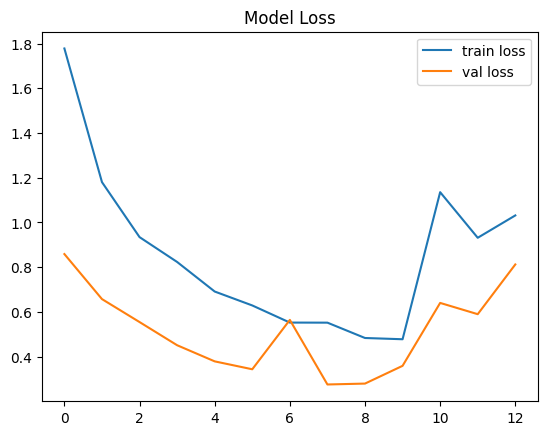

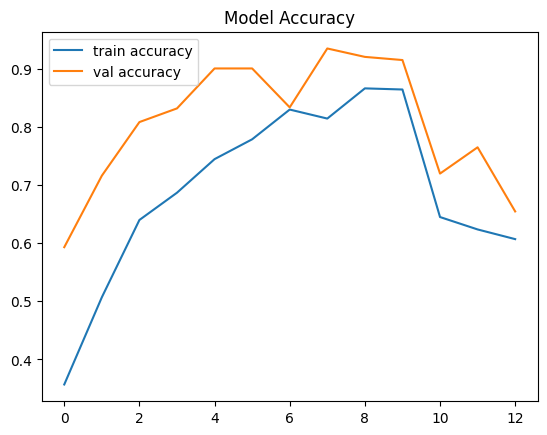

In [98]:
plot_loss_history(history)

#### Evaluation


In [99]:
print(f"RNN trained on Exclusive Sequences, tested on Exclusive Sequences - {denoising_filter}")

loss, accuracy = model.evaluate(
    eval(f"X_test_RA_amplitude_denoised_exclusive"), eval(f"y_test_RA_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room A: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RB_door_close_amplitude_denoised_exclusive"), eval(f"y_test_RB_door_close_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room B (door closed): {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RB_amplitude_denoised_exclusive"), eval(f"y_test_RB_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room B: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RC_amplitude_denoised_exclusive"), eval(f"y_test_RC_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room C: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RD_amplitude_denoised_exclusive"), eval(f"y_test_RD_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room D: {(accuracy * 100):.2f}%")



print(f"RNN trained on Exclusive Sequences, tested on Sliding Sequences - {denoising_filter}")

loss, accuracy = model.evaluate(
    eval(f"X_test_RA_amplitude_denoised_sliding"), eval(f"y_test_RA_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room A: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RB_door_close_amplitude_denoised_sliding"), eval(f"y_test_RB_door_close_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room B (door closed): {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RB_amplitude_denoised_sliding"), eval(f"y_test_RB_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room B: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RC_amplitude_denoised_sliding"), eval(f"y_test_RC_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room C: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RD_amplitude_denoised_sliding"), eval(f"y_test_RD_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room D: {(accuracy * 100):.2f}%")

RNN trained on Exclusive Sequences, tested on Exclusive Sequences - butter_lowpass
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9385 - loss: 0.2613
Test Accuracy in room A: 94.40%
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.1719 - loss: 5.2006
Test Accuracy in room B (door closed): 18.52%
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.2845 - loss: 4.4676
Test Accuracy in room B: 30.57%
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.0971 - loss: 5.6964
Test Accuracy in room C: 10.48%
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.1496 - loss: 5.8875
Test Accuracy in room D: 15.61%
RNN trained on Exclusive Sequences, tested on Sliding Sequences - butter_lowpass
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9266 - loss: 0.2990
Test Accuracy in room A: 92.18%
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.1633 - loss: 5.4459
Test Accuracy in room B (door closed): 17.48%
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.3324 - loss:

### On Sliding sequences

In [100]:
model = create_rnn()

In [101]:
early_stopping_5 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

In [102]:
history = model.fit(
    X_train_sliding,
    y_train_sliding,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(
        X_val_sliding,
        y_val_sliding,
    ),
    callbacks=[early_stopping_5],
)

Epoch 1/20
323/323 ━━━━━━━━━━━━━━━━━━━━ 33s 90ms/step - accuracy: 0.4307 - loss: 1.4806 - val_accuracy: 0.8101 - val_loss: 0.4966
Epoch 2/20
323/323 ━━━━━━━━━━━━━━━━━━━━ 28s 86ms/step - accuracy: 0.7671 - loss: 0.6229 - val_accuracy: 0.9358 - val_loss: 0.2483
Epoch 3/20
323/323 ━━━━━━━━━━━━━━━━━━━━ 28s 86ms/step - accuracy: 0.8713 - loss: 0.4377 - val_accuracy: 0.9421 - val_loss: 0.2360
Epoch 4/20
323/323 ━━━━━━━━━━━━━━━━━━━━ 28s 87ms/step - accuracy: 0.9253 - loss: 0.2835 - val_accuracy: 0.9458 - val_loss: 0.2195
Epoch 5/20
323/323 ━━━━━━━━━━━━━━━━━━━━ 28s 87ms/step - accuracy: 0.9446 - loss: 0.2139 - val_accuracy: 0.9498 - val_loss: 0.1982
Epoch 6/20
323/323 ━━━━━━━━━━━━━━━━━━━━ 28s 86ms/step - accuracy: 0.9373 - loss: 0.2386 - val_accuracy: 0.9512 - val_loss: 0.2000
Epoch 7/20
323/323 ━━━━━━━━━━━━━━━━━━━━ 41s 87ms/step - accuracy: 0.9522 - loss: 0.1955 - val_accuracy: 0.9584 - val_loss: 0.1549
Epoch 8/20
323/323 ━━━━━━━━━━━━━━━━━━━━ 28s 86ms/step - accuracy: 0.9557 - loss: 0.1742 - 

In [103]:
model.save(
    f"/kaggle/working/RNN_R{room_name}_amplitude_{denoising_filter}_sliding_sequences.keras"
)

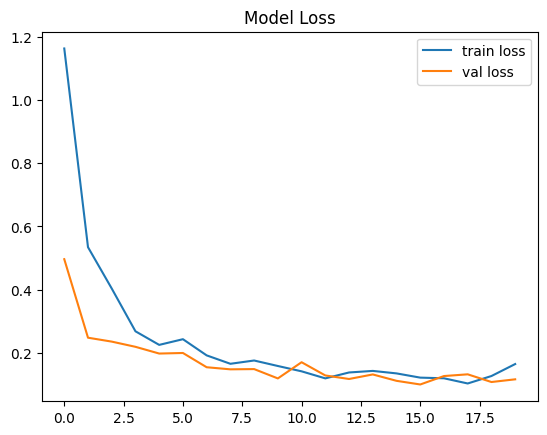

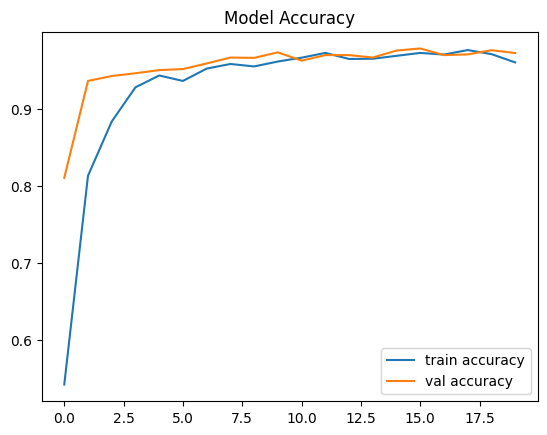

In [104]:
plot_loss_history(history)

#### Evaluation


In [105]:
print(f"RNN trained on Sliding Sequences, tested on Exclusive Sequences - {denoising_filter}")

loss, accuracy = model.evaluate(
    eval(f"X_test_RA_amplitude_denoised_exclusive"), eval(f"y_test_RA_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room A: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RB_door_close_amplitude_denoised_exclusive"), eval(f"y_test_RB_door_close_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room B (door closed): {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RB_amplitude_denoised_exclusive"), eval(f"y_test_RB_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room B: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RC_amplitude_denoised_exclusive"), eval(f"y_test_RC_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room C: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RD_amplitude_denoised_exclusive"), eval(f"y_test_RD_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room D: {(accuracy * 100):.2f}%")



print(f"RNN trained on Sliding Sequences, tested on Sliding Sequences - {denoising_filter}")

loss, accuracy = model.evaluate(
    eval(f"X_test_RA_amplitude_denoised_sliding"), eval(f"y_test_RA_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room A: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RB_door_close_amplitude_denoised_sliding"), eval(f"y_test_RB_door_close_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room B (door closed): {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RB_amplitude_denoised_sliding"), eval(f"y_test_RB_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room B: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RC_amplitude_denoised_sliding"), eval(f"y_test_RC_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room C: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RD_amplitude_denoised_sliding"), eval(f"y_test_RD_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room D: {(accuracy * 100):.2f}%")

RNN trained on Sliding Sequences, tested on Exclusive Sequences - butter_lowpass
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9832 - loss: 0.0688
Test Accuracy in room A: 98.74%
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.1678 - loss: 6.3813
Test Accuracy in room B (door closed): 17.27%
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.2750 - loss: 5.9241
Test Accuracy in room B: 27.39%
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2614 - loss: 6.0998
Test Accuracy in room C: 26.43%
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.1587 - loss: 7.3375
Test Accuracy in room D: 16.52%
RNN trained on Sliding Sequences, tested on Sliding Sequences - butter_lowpass
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9770 - loss: 0.0926
Test Accuracy in room A: 97.38%
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.1608 - loss: 6.4028
Test Accuracy in room B (door closed): 16.50%
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.2427 - loss: 5.9

## GRU


In [106]:
from tensorflow.keras import Input, regularizers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GRU, LayerNormalization
from tensorflow.keras.initializers import GlorotUniform, Orthogonal, Constant

### Model architecture

In [114]:
# Hyperparameters
learning_rate = 0.0001
l2_reg = 0.0001
epochs = 20
batch_size = 32
momentum = 0.9
num_classes = y_train_exclusive.shape[1]
input_features = X_train_exclusive.shape[2]

In [115]:
def create_gru():
    inputs = Input(shape=(T, input_features))

    x = GRU(64, return_sequences=True, kernel_regularizer=l2(l2_reg), kernel_initializer=GlorotUniform(), recurrent_initializer=Orthogonal())(inputs)
    x = LayerNormalization()(x)
    x = Dropout(0.25)(x)

    x = GRU(128, kernel_regularizer=l2(l2_reg), kernel_initializer=GlorotUniform(), recurrent_initializer=Orthogonal())(x)
    x = LayerNormalization()(x)
    x = Dropout(0.4)(x)

    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs=inputs, outputs=outputs)

    optimizer_sgd = tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=momentum)
    optimizer_adamw = tf.keras.optimizers.AdamW(learning_rate=learning_rate)
    model.compile(optimizer=optimizer_adamw, loss="categorical_crossentropy", metrics=["accuracy"])

    return model

### On Exclusive Sequences


In [116]:
model = create_gru()

In [117]:
early_stopping_5 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train_exclusive,
    y_train_exclusive,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val_exclusive, y_val_exclusive),
    callbacks=[early_stopping_5],
)

Epoch 1/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 26s 259ms/step - accuracy: 0.2974 - loss: 2.1017 - val_accuracy: 0.6600 - val_loss: 0.8322
Epoch 2/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 21s 255ms/step - accuracy: 0.5363 - loss: 1.1144 - val_accuracy: 0.8409 - val_loss: 0.6286
Epoch 3/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 21s 256ms/step - accuracy: 0.6604 - loss: 0.8787 - val_accuracy: 0.8662 - val_loss: 0.5297
Epoch 4/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 21s 262ms/step - accuracy: 0.7240 - loss: 0.7417 - val_accuracy: 0.8933 - val_loss: 0.4552
Epoch 5/20
58/81 ━━━━━━━━━━━━━━━━━━━━ 5s 250ms/step - accuracy: 0.7619 - loss: 0.6611

In [ ]:
model.save(
    f"/kaggle/working/GRU_R{room_name}_amplitude_{denoising_filter}_exclusive_sequences.keras"
)

In [ ]:
plot_loss_history(history)

#### Evaluation


In [ ]:
print(f"GRU trained on Exclusive Sequences, tested on Exclusive Sequences - {denoising_filter}")

loss, accuracy = model.evaluate(
    eval(f"X_test_RA_amplitude_denoised_exclusive"), eval(f"y_test_RA_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room A: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RB_door_close_amplitude_denoised_exclusive"), eval(f"y_test_RB_door_close_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room B (door closed): {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RB_amplitude_denoised_exclusive"), eval(f"y_test_RB_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room B: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RC_amplitude_denoised_exclusive"), eval(f"y_test_RC_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room C: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RD_amplitude_denoised_exclusive"), eval(f"y_test_RD_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room D: {(accuracy * 100):.2f}%")



print(f"GRU trained on Exclusive Sequences, tested on Sliding Sequences - {denoising_filter}")

loss, accuracy = model.evaluate(
    eval(f"X_test_RA_amplitude_denoised_sliding"), eval(f"y_test_RA_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room A: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RB_door_close_amplitude_denoised_sliding"), eval(f"y_test_RB_door_close_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room B (door closed): {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RB_amplitude_denoised_sliding"), eval(f"y_test_RB_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room B: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RC_amplitude_denoised_sliding"), eval(f"y_test_RC_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room C: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RD_amplitude_denoised_sliding"), eval(f"y_test_RD_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room D: {(accuracy * 100):.2f}%")

### On Sliding Sequences


In [ ]:
model = create_gru()

In [ ]:
early_stopping_5 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train_sliding,
    y_train_sliding,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val_sliding, y_val_sliding),
    callbacks=[early_stopping_5],
)

In [ ]:
model.save(
    f"/kaggle/working/GRU_R{room_name}_amplitude_{denoising_filter}_sliding_sequences.keras"
)

In [ ]:
plot_loss_history(history)

#### Evaluation


In [ ]:
print(f"GRU trained on Sliding Sequences, tested on Exclusive Sequences - {denoising_filter}")

loss, accuracy = model.evaluate(
    eval(f"X_test_RA_amplitude_denoised_exclusive"), eval(f"y_test_RA_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room A: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RB_door_close_amplitude_denoised_exclusive"), eval(f"y_test_RB_door_close_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room B (door closed): {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RB_amplitude_denoised_exclusive"), eval(f"y_test_RB_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room B: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RC_amplitude_denoised_exclusive"), eval(f"y_test_RC_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room C: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RD_amplitude_denoised_exclusive"), eval(f"y_test_RD_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room D: {(accuracy * 100):.2f}%")



print(f"GRU trained on Sliding Sequences, tested on Sliding Sequences - {denoising_filter}")

loss, accuracy = model.evaluate(
    eval(f"X_test_RA_amplitude_denoised_sliding"), eval(f"y_test_RA_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room A: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RB_door_close_amplitude_denoised_sliding"), eval(f"y_test_RB_door_close_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room B (door closed): {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RB_amplitude_denoised_sliding"), eval(f"y_test_RB_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room B: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RC_amplitude_denoised_sliding"), eval(f"y_test_RC_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room C: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RD_amplitude_denoised_sliding"), eval(f"y_test_RD_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room D: {(accuracy * 100):.2f}%")

## LSTM



In [ ]:
from tensorflow.keras import Input, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, BatchNormalization

### Model Architecture


In [ ]:
# Hyperparameters
learning_rate = 0.0001
l2_reg = 0.0001
epochs = 20
batch_size = 32
momentum = 0.9
num_classes = y_train_exclusive.shape[1]
input_features = X_train_exclusive.shape[2]

In [ ]:
def create_lstm():
    inputs = Input(shape=(T, input_features))

    x = LSTM(64, return_sequences=True, 
             kernel_regularizer=l2(l2_reg),
             kernel_initializer=GlorotUniform(),
             recurrent_initializer=Orthogonal(),)(inputs)
    x = LayerNormalization()(x)
    x = Dropout(0.25)(x)

    x = LSTM(128, kernel_regularizer=l2(l2_reg), 
             kernel_initializer=GlorotUniform(), 
             recurrent_initializer=Orthogonal(),)(x)
    x = LayerNormalization()(x)
    x = Dropout(0.4)(x)

    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs=inputs, outputs=outputs)

    optimizer_sgd = tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=momentum)
    optimizer_adamw = tf.keras.optimizers.AdamW(learning_rate=learning_rate)
    model.compile(optimizer=optimizer_adamw, loss="categorical_crossentropy", metrics=["accuracy"])

    return model

### On Exclusive Sequences


In [ ]:
model = create_lstm()

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train_exclusive,
    y_train_exclusive,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val_exclusive, y_val_exclusive),
    callbacks=[early_stopping],
)

In [ ]:
model.save(
    f"/kaggle/working/LSTM_R{room_name}_amplitude_{denoising_filter}_exclusive_sequences.keras"
)

In [ ]:
plot_loss_history(history)

#### Evaluation

In [ ]:
print(f"LSTM trained on Exclusive Sequences, tested on Exclusive Sequences - {denoising_filter}")

loss, accuracy = model.evaluate(
    eval(f"X_test_RA_amplitude_denoised_exclusive"), eval(f"y_test_RA_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room A: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RB_door_close_amplitude_denoised_exclusive"), eval(f"y_test_RB_door_close_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room B (door closed): {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RB_amplitude_denoised_exclusive"), eval(f"y_test_RB_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room B: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RC_amplitude_denoised_exclusive"), eval(f"y_test_RC_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room C: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RD_amplitude_denoised_exclusive"), eval(f"y_test_RD_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room D: {(accuracy * 100):.2f}%")



print(f"LSTM trained on Exclusive Sequences, tested on Sliding Sequences - {denoising_filter}")

loss, accuracy = model.evaluate(
    eval(f"X_test_RA_amplitude_denoised_sliding"), eval(f"y_test_RA_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room A: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RB_door_close_amplitude_denoised_sliding"), eval(f"y_test_RB_door_close_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room B (door closed): {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RB_amplitude_denoised_sliding"), eval(f"y_test_RB_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room B: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RC_amplitude_denoised_sliding"), eval(f"y_test_RC_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room C: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RD_amplitude_denoised_sliding"), eval(f"y_test_RD_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room D: {(accuracy * 100):.2f}%")

### On Sliding Sequences


In [ ]:
model = create_lstm()

In [ ]:
early_stopping_5 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train_sliding,
    y_train_sliding,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val_sliding, y_val_sliding),
    callbacks=[early_stopping_5],
)

In [ ]:
model.save(
    f"/kaggle/working/LSTM_R{room_name}_amplitude_{denoising_filter}_sliding_sequences.keras"
)

In [ ]:
plot_loss_history(history)

#### Evaluation

In [ ]:
print(f"LSTM trained on Sliding Sequences, tested on Exclusive Sequences - {denoising_filter}")
loss, accuracy = model.evaluate(
    eval(f"X_test_RA_amplitude_denoised_exclusive"), eval(f"y_test_RA_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room A: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RB_door_close_amplitude_denoised_exclusive"), eval(f"y_test_RB_door_close_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room B (door closed): {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RB_amplitude_denoised_exclusive"), eval(f"y_test_RB_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room B: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RC_amplitude_denoised_exclusive"), eval(f"y_test_RC_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room C: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RD_amplitude_denoised_exclusive"), eval(f"y_test_RD_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room D: {(accuracy * 100):.2f}%")



print(f"LSTM trained on Sliding Sequences, tested on Sliding Sequences - {denoising_filter}")

loss, accuracy = model.evaluate(
    eval(f"X_test_RA_amplitude_denoised_sliding"), eval(f"y_test_RA_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room A: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RB_door_close_amplitude_denoised_sliding"), eval(f"y_test_RB_door_close_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room B (door closed): {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RB_amplitude_denoised_sliding"), eval(f"y_test_RB_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room B: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RC_amplitude_denoised_sliding"), eval(f"y_test_RC_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room C: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RD_amplitude_denoised_sliding"), eval(f"y_test_RD_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room D: {(accuracy * 100):.2f}%")

## BLSTM


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    LSTM,
    Bidirectional,
    BatchNormalization,
    Input,
)
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.regularizers import l2

### Model Architecture


In [ ]:
# Hyperparameters
learning_rate = 0.0001
l2_reg = 0.0001
epochs = 20
batch_size = 32
momentum = 0.9
num_classes = y_train_exclusive.shape[1]
input_features = X_train_exclusive.shape[2]

In [ ]:
def create_blstm():
    inputs = Input(shape=(T, input_features))

    x = Bidirectional(
            LSTM(
             64,
             return_sequences=True, 
             kernel_regularizer=l2(l2_reg),
             kernel_initializer=GlorotUniform(),
             recurrent_initializer=Orthogonal()
            ))(inputs)
    x = LayerNormalization()(x)
    x = Dropout(0.25)(x)

    x = Bidirectional(
            LSTM(
             128,
             kernel_regularizer=l2(l2_reg), 
             kernel_initializer=GlorotUniform(), 
             recurrent_initializer=Orthogonal()
            ))(x)
    x = LayerNormalization()(x)
    x = Dropout(0.4)(x)

    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs=inputs, outputs=outputs)

    optimizer_sgd = tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=momentum)
    optimizer_adamw = tf.keras.optimizers.AdamW(learning_rate=learning_rate)
    model.compile(optimizer=optimizer_adamw, loss="categorical_crossentropy", metrics=["accuracy"])

    return model

### On Exclusive Sequences


In [ ]:
model = create_blstm()

In [ ]:
early_stopping_5 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train_exclusive,
    y_train_exclusive,
    validation_data=(X_val_exclusive, y_val_exclusive),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping_5],
)

In [ ]:
model.save(
    f"/kaggle/working/BLSTM_R{room_name}_amplitude_{denoising_filter}_exclsuive_sequences.keras"
)

In [ ]:
plot_loss_history(history)

#### Evaluation

In [ ]:
print(f"BLSTM trained on Exclusive Sequences, tested on Exclusive Sequences - {denoising_filter}")

loss, accuracy = model.evaluate(
    eval(f"X_test_RA_amplitude_denoised_exclusive"), eval(f"y_test_RA_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room A: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RB_door_close_amplitude_denoised_exclusive"), eval(f"y_test_RB_door_close_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room B (door closed): {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RB_amplitude_denoised_exclusive"), eval(f"y_test_RB_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room B: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RC_amplitude_denoised_exclusive"), eval(f"y_test_RC_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room C: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RD_amplitude_denoised_exclusive"), eval(f"y_test_RD_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room D: {(accuracy * 100):.2f}%")



print(f"BLSTM trained on Exclusive Sequences, tested on Sliding Sequences - {denoising_filter}")

loss, accuracy = model.evaluate(
    eval(f"X_test_RA_amplitude_denoised_sliding"), eval(f"y_test_RA_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room A: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RB_door_close_amplitude_denoised_sliding"), eval(f"y_test_RB_door_close_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room B (door closed): {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RB_amplitude_denoised_sliding"), eval(f"y_test_RB_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room B: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RC_amplitude_denoised_sliding"), eval(f"y_test_RC_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room C: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RD_amplitude_denoised_sliding"), eval(f"y_test_RD_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room D: {(accuracy * 100):.2f}%")

### On Sliding Sequences


In [ ]:
model = create_blstm()

In [ ]:
early_stopping_5 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train_sliding,
    y_train_sliding,
    validation_data=(X_val_sliding, y_val_sliding),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping_5],
)

In [ ]:
model.save(
    f"/kaggle/working/BLSTM_R{room_name}_amplitude_{denoising_filter}_sliding_sequences.keras"
)

In [ ]:
plot_loss_history(history)

#### Evaluation

In [ ]:
print(f"BLSTM trained on Sliding Sequences, tested on Exclusive Sequences - {denoising_filter}")

loss, accuracy = model.evaluate(
    eval(f"X_test_RA_amplitude_denoised_exclusive"), eval(f"y_test_RA_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room A: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RB_door_close_amplitude_denoised_exclusive"), eval(f"y_test_RB_door_close_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room B (door closed): {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RB_amplitude_denoised_exclusive"), eval(f"y_test_RB_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room B: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RC_amplitude_denoised_exclusive"), eval(f"y_test_RC_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room C: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RD_amplitude_denoised_exclusive"), eval(f"y_test_RD_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room D: {(accuracy * 100):.2f}%")



print(f"BLSTM trained on Sliding Sequences, tested on Sliding Sequences - {denoising_filter}")

loss, accuracy = model.evaluate(
    eval(f"X_test_RA_amplitude_denoised_sliding"), eval(f"y_test_RA_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room A: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RB_door_close_amplitude_denoised_sliding"), eval(f"y_test_RB_door_close_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room B (door closed): {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RB_amplitude_denoised_sliding"), eval(f"y_test_RB_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room B: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RC_amplitude_denoised_sliding"), eval(f"y_test_RC_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room C: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RD_amplitude_denoised_sliding"), eval(f"y_test_RD_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room D: {(accuracy * 100):.2f}%")

## CNN + BLSTM



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    LSTM,
    Dense,
    Dropout,
    MaxPooling1D,
    Bidirectional,
    BatchNormalization,
    Add,
)

### Model Architecture


In [ ]:
# Hyperparameters
learning_rate = 0.0001
l2_reg = 0.0001
epochs = 20
batch_size = 32
momentum = 0.9
num_classes = y_train_exclusive.shape[1]
input_features = X_train_exclusive.shape[2]

In [ ]:
def create_cnnblstm():
    inputs = Input(shape=(T, input_features))

    x = Conv1D(filters=64, kernel_size=3, activation="relu")(inputs)
    x = MaxPooling1D(pool_size=2)(x)
    x = Conv1D(filters=64, kernel_size=3, activation="relu")(x)
    x = MaxPooling1D(pool_size=2)(x)

    x = Bidirectional(
          LSTM(64,
             return_sequences=True, 
             kernel_regularizer=l2(l2_reg),
             kernel_initializer=GlorotUniform(),
             recurrent_initializer=Orthogonal(),
          ))(x)
    x = LayerNormalization()(x)
    x = Dropout(0.25)(x)

    x = Bidirectional(
          LSTM(128,
             return_sequences=False,
             kernel_regularizer=l2(l2_reg), 
             kernel_initializer=GlorotUniform(), 
             recurrent_initializer=Orthogonal(),
          ))(x)
    x = LayerNormalization()(x)
    x = Dropout(0.4)(x)
    
    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs=inputs, outputs=outputs)

    optimizer_adamw = tf.keras.optimizers.AdamW(learning_rate=learning_rate)
    model.compile(optimizer=optimizer_adamw, loss="categorical_crossentropy", metrics=["accuracy"])

    return model

### On Exclusive Sequences


In [ ]:
model = create_cnnblstm()

In [ ]:
early_stopping_5 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train_exclusive,
    y_train_exclusive,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val_exclusive, y_val_exclusive),
    callbacks=[early_stopping_5],
)

In [ ]:
model.save(
    f"/kaggle/working/CNN_BLSTM_R{room_name}_amplitude_{denoising_filter}_exclusive_sequences.keras"
)

In [ ]:
plot_loss_history(history)

#### Evaluation

In [ ]:
print(f"CNN-BLSTM trained on Exclusive Sequences, tested on Exclusive Sequences - {denoising_filter}")

loss, accuracy = model.evaluate(
    eval(f"X_test_RA_amplitude_denoised_exclusive"), eval(f"y_test_RA_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room A: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RB_door_close_amplitude_denoised_exclusive"), eval(f"y_test_RB_door_close_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room B (door closed): {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RB_amplitude_denoised_exclusive"), eval(f"y_test_RB_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room B: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RC_amplitude_denoised_exclusive"), eval(f"y_test_RC_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room C: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RD_amplitude_denoised_exclusive"), eval(f"y_test_RD_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room D: {(accuracy * 100):.2f}%")



print(f"CNN-BLSTM trained on Exclusive Sequences, tested on Sliding Sequences - {denoising_filter}")

loss, accuracy = model.evaluate(
    eval(f"X_test_RA_amplitude_denoised_sliding"), eval(f"y_test_RA_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room A: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RB_door_close_amplitude_denoised_sliding"), eval(f"y_test_RB_door_close_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room B (door closed): {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RB_amplitude_denoised_sliding"), eval(f"y_test_RB_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room B: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RC_amplitude_denoised_sliding"), eval(f"y_test_RC_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room C: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RD_amplitude_denoised_sliding"), eval(f"y_test_RD_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room D: {(accuracy * 100):.2f}%")

### On Sliding Sequences


In [ ]:
model = create_cnnblstm()

In [ ]:
early_stopping_5 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train_sliding,
    y_train_sliding,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val_sliding, y_val_sliding),
    callbacks=[early_stopping_5],
)

In [ ]:
model.save(
    f"/kaggle/working/CNN_BLSTM_R{room_name}_amplitude_{denoising_filter}_sliding_sequences.keras"
)

In [ ]:
plot_loss_history(history)

#### Evaluation

In [ ]:
print(f"CNN-BLSTM trained on Sliding Sequences, tested on Exclusive Sequences - {denoising_filter}")

loss, accuracy = model.evaluate(
    eval(f"X_test_RA_amplitude_denoised_exclusive"), eval(f"y_test_RA_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room A: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RB_door_close_amplitude_denoised_exclusive"), eval(f"y_test_RB_door_close_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room B (door closed): {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RB_amplitude_denoised_exclusive"), eval(f"y_test_RB_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room B: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RC_amplitude_denoised_exclusive"), eval(f"y_test_RC_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room C: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RD_amplitude_denoised_exclusive"), eval(f"y_test_RD_amplitude_denoised_exclusive")
)
print(f"Test Accuracy in room D: {(accuracy * 100):.2f}%")



print(f"CNN-BLSTM trained on Sliding Sequences, tested on Sliding Sequences - {denoising_filter}")

loss, accuracy = model.evaluate(
    eval(f"X_test_RA_amplitude_denoised_sliding"), eval(f"y_test_RA_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room A: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RB_door_close_amplitude_denoised_sliding"), eval(f"y_test_RB_door_close_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room B (door closed): {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RB_amplitude_denoised_sliding"), eval(f"y_test_RB_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room B: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RC_amplitude_denoised_sliding"), eval(f"y_test_RC_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room C: {(accuracy * 100):.2f}%")

loss, accuracy = model.evaluate(
    eval(f"X_test_RD_amplitude_denoised_sliding"), eval(f"y_test_RD_amplitude_denoised_sliding")
)
print(f"Test Accuracy in room D: {(accuracy * 100):.2f}%")

In [ ]:
# import os
# import zipfile

# def zip_directory(directory_path):
#     # Define the name of the zip file (you can customize the name as needed)
#     zip_file_name = os.path.basename(directory_path.rstrip('/')) + ".zip"
#     zip_file_path = os.path.join(directory_path, zip_file_name)
    
#     # Create a zip file
#     with zipfile.ZipFile(zip_file_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
#         # Traverse through all files in the directory
#         for foldername, subfolders, filenames in os.walk(directory_path):
#             for filename in filenames:
#                 file_path = os.path.join(foldername, filename)
#                 # Skip adding the zip file to itself
#                 if file_path == zip_file_path:
#                     continue
#                 # Add file to the zip archive
#                 zipf.write(file_path, os.path.relpath(file_path, directory_path))
    
#     print(f"Zip file created: {zip_file_path}")

# # Example usage
# directory_to_zip = "/kaggle/working/"  # Replace with your directory path
# zip_directory(directory_to_zip)